In [1]:
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.util import fetch_wasabi_file
from histpy import Histogram

from scoords import SpacecraftFrame

from astropy.time import Time
import astropy.units as u
from astropy.coordinates import SkyCoord, Galactic

import numpy as np
import matplotlib.pyplot as plt

from threeML import *
from threeML.io.package_data import get_path_of_data_file
from threeML.io.logging import silence_console_log
from astromodels import Parameter
from threeML.minimizer.minimization import CannotComputeCovariance

from jupyterthemes import jtplot
jtplot.style(context="talk", fscale=1, ticks=True, grid=False)
set_threeML_style()
silence_warnings()

from scipy.integrate import quad

import matplotlib.ticker as mticker

from pathlib import Path

import os

%matplotlib inline

23:27:48 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=100228;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=738219;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=540467;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=809948;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=613296;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=888388;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

23:27:48 INFO      Starting 3ML!                                                                     ]8;id=552251;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=917198;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#44\44]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=597393;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=312666;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#45\45]8;;\

...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=639590;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=490349;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

         WARNING   No fermitools installed                                              ]8;id=647653;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=260487;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=982439;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=819980;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=558246;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=864969;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=51218;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=445221;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

In [2]:
data_path = Path("/Users/parshadkp/Software/COSI_Data/")

In [3]:
from agn_cosi_fit_utils import open_spacecraft_history
sc_orientation = open_spacecraft_history("/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits")

In [4]:
dr = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5"

In [5]:
multiplier_4151 = 1
multiplier_1068 = 1

exposure_4151 = multiplier_4151 * 3
exposure_1068 = multiplier_1068 * 3

## Cutoff Power Law (Thermal)

#### NGC 4151 (200 keV)

In [6]:
K_inj = 0.15*multiplier_4151 / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 200. * u.keV
index_inj = -1.75

spectrum_inj_ec200 = Cutoff_powerlaw()

spectrum_inj_ec200.K.value = K_inj.value
spectrum_inj_ec200.piv.value = piv_inj.value
spectrum_inj_ec200.xc.value = xc_inj.value
spectrum_inj_ec200.index.value = index_inj

spectrum_inj_ec200.K.unit = K_inj.unit
spectrum_inj_ec200.piv.unit = piv_inj.unit
spectrum_inj_ec200.xc.unit = xc_inj.unit

#### NGC 4151 (1000 keV)

In [7]:
K_inj = 0.15*multiplier_4151 / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 1000. * u.keV
index_inj = -1.75

spectrum_inj_ec1000 = Cutoff_powerlaw()

spectrum_inj_ec1000.K.value = K_inj.value
spectrum_inj_ec1000.piv.value = piv_inj.value
spectrum_inj_ec1000.xc.value = xc_inj.value
spectrum_inj_ec1000.index.value = index_inj

spectrum_inj_ec1000.K.unit = K_inj.unit
spectrum_inj_ec1000.piv.unit = piv_inj.unit
spectrum_inj_ec1000.xc.unit = xc_inj.unit

## Cutoff Powerlaw (Non-thermal)

#### NGC 4151 (200 keV) Non-thermal cutoff

In [8]:
# K_inj = 0.1*spectrum_inj_ec200.evaluate_at(1000) / u.cm / u.cm / u.s / u.keV
# piv_inj = 1000. * u.keV

def cutoff_powerlaw_k_at_pivot(shape, pivot_value):
    return float(shape.K.value * (pivot_value / shape.piv.value) ** shape.index.value)

K_inj = 0.1*spectrum_inj_ec200.evaluate_at(1) / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
index_inj = -1.7
cutoff_inj = 2000. * u.keV

spectrum_inj_ec200_PL = Cutoff_powerlaw()

spectrum_inj_ec200_PL.K.value = K_inj.value
spectrum_inj_ec200_PL.piv.value = piv_inj.value
spectrum_inj_ec200_PL.index.value = index_inj
spectrum_inj_ec200_PL.xc.value = cutoff_inj.value

spectrum_inj_ec200_PL.K.unit = K_inj.unit
spectrum_inj_ec200_PL.piv.unit = piv_inj.unit
spectrum_inj_ec200_PL.xc.unit = cutoff_inj.unit

spectrum_inj_ec200_total = spectrum_inj_ec200 + spectrum_inj_ec200_PL

print(spectrum_inj_ec200.evaluate_at(200))
print(spectrum_inj_ec200_PL.evaluate_at(200))
print("="*40)
linking_ratio_ec200 = spectrum_inj_ec200_PL.K.value / cutoff_powerlaw_k_at_pivot(
    spectrum_inj_ec200,
    spectrum_inj_ec200_PL.piv.value,
)
print("Linking K ratio", linking_ratio_ec200)
print("Flux ratio at 200 keV", spectrum_inj_ec200_PL.evaluate_at(200)/spectrum_inj_ec200.evaluate_at(200))
print("="*40)
flux_th, _ = quad(spectrum_inj_ec200.evaluate_at, 200.0, 5000.0)
flux_nth, _ = quad(spectrum_inj_ec200_PL.evaluate_at, 200.0, 5000.0)
print("Non-thermal flux: ", flux_nth)
print("Total flux: ", flux_th + flux_nth)
print("Thermal - Non-thermal Flux Ratio: ", flux_th/flux_nth)
print("Non-thermal percentage: ", flux_nth/(flux_th + flux_nth))

energy_flux_kev, energy_flux_kev_err = quad(
    lambda E: E * (spectrum_inj_ec200 + spectrum_inj_ec200_PL).evaluate_at(E),
    200.0,
    5000.0,
)

energy_flux = (energy_flux_kev * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)
energy_flux_err = (energy_flux_kev_err * u.keV / u.cm**2 / u.s).to(u.erg / u.cm**2 / u.s)

print("energy_flux: ", energy_flux)
print("energy_flux_err: ", energy_flux_err)

K_inj_at_fit_pivot = (
    spectrum_inj_ec200.K.value
    * (200.0 / spectrum_inj_ec200.piv.value) ** spectrum_inj_ec200.index.value
)

print(K_inj_at_fit_pivot)

5.187932116320825e-06
1.6547765042367583e-06
Linking K ratio 0.09950124791926825
Flux ratio at 200 keV 0.31896649129832716
Non-thermal flux:  0.0003303568567501931
Total flux:  0.0007877361163275843
Thermal - Non-thermal Flux Ratio:  1.3845005793939036
Non-thermal percentage:  0.4193750291535604
energy_flux:  5.319431102429163e-10 erg / (s cm2)
energy_flux_err:  2.648326826318879e-20 erg / (s cm2)
1.4102261599073975e-05


#### NGC 4151 (1000 keV) Non-thermal cutoff

In [9]:
# K_inj = 0.1*spectrum_inj_ec200.evaluate_at(1000) / u.cm / u.cm / u.s / u.keV
# piv_inj = 1000. * u.keV

K_inj = 0.15*spectrum_inj_ec1000.evaluate_at(200) / u.cm / u.cm / u.s / u.keV
piv_inj = 200. * u.keV
index_inj = -1.7
cutoff_inj = 1500. * u.keV

spectrum_inj_ec1000_PL = Cutoff_powerlaw()

spectrum_inj_ec1000_PL.K.value = K_inj.value
spectrum_inj_ec1000_PL.piv.value = piv_inj.value
spectrum_inj_ec1000_PL.index.value = index_inj
spectrum_inj_ec1000_PL.xc.value = cutoff_inj.value

spectrum_inj_ec1000_PL.K.unit = K_inj.unit
spectrum_inj_ec1000_PL.piv.unit = piv_inj.unit
spectrum_inj_ec1000_PL.xc.unit = cutoff_inj.unit

spectrum_inj_ec1000_total = spectrum_inj_ec1000 + spectrum_inj_ec1000_PL

print(spectrum_inj_ec1000.evaluate_at(200))
print(spectrum_inj_ec1000_PL.evaluate_at(200))
print("="*40)
linking_ratio_ec1000 = spectrum_inj_ec1000_PL.K.value / cutoff_powerlaw_k_at_pivot(
    spectrum_inj_ec1000,
    spectrum_inj_ec1000_PL.piv.value,
)
print("Linking K ratio", linking_ratio_ec1000)
print("Flux ratio at 200 keV", spectrum_inj_ec1000_PL.evaluate_at(200)/spectrum_inj_ec1000.evaluate_at(200))
print("="*40)
flux_th, _ = quad(spectrum_inj_ec1000.evaluate_at, 200.0, 5000.0)
flux_nth, _ = quad(spectrum_inj_ec1000_PL.evaluate_at, 200.0, 5000.0)
print("Non-thermal flux: ", flux_nth)
print("Total flux: ", flux_th + flux_nth)
print("Thermal - Non-thermal Flux Ratio: ", flux_th/flux_nth)
print("Non-thermal percentage: ", flux_nth/(flux_th + flux_nth))

1.1545955259112548e-05
1.515706797845836e-06
Linking K ratio 0.12280961296169741
Flux ratio at 200 keV 0.13127599785644217
Non-thermal flux:  0.0002849389016566267
Total flux:  0.0021804712446901213
Thermal - Non-thermal Flux Ratio:  6.652416823441528
Non-thermal percentage:  0.13067766995346042


In [10]:
# energy = np.geomspace(200*u.keV,5*u.MeV).to_value(u.keV)
# energy = np.geomspace(200*u.keV,5*u.MeV).to_value(u.keV)
energy = np.geomspace(200*u.keV,5*u.MeV).to_value(u.keV)

flux_inj_ec200 = np.zeros_like(energy)
flux_inj_ec1000 = np.zeros_like(energy)
flux_inj_ec200_PL = np.zeros_like(energy)
flux_inj_ec1000_PL = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux_inj_ec1000[i] = spectrum_inj_ec1000.evaluate_at(e)
    flux_inj_ec200[i] = spectrum_inj_ec200.evaluate_at(e)
    flux_inj_ec200_PL[i] = spectrum_inj_ec200_PL.evaluate_at(e)
    flux_inj_ec1000_PL[i] = spectrum_inj_ec1000_PL.evaluate_at(e)

Plot the fitted and injected spectra

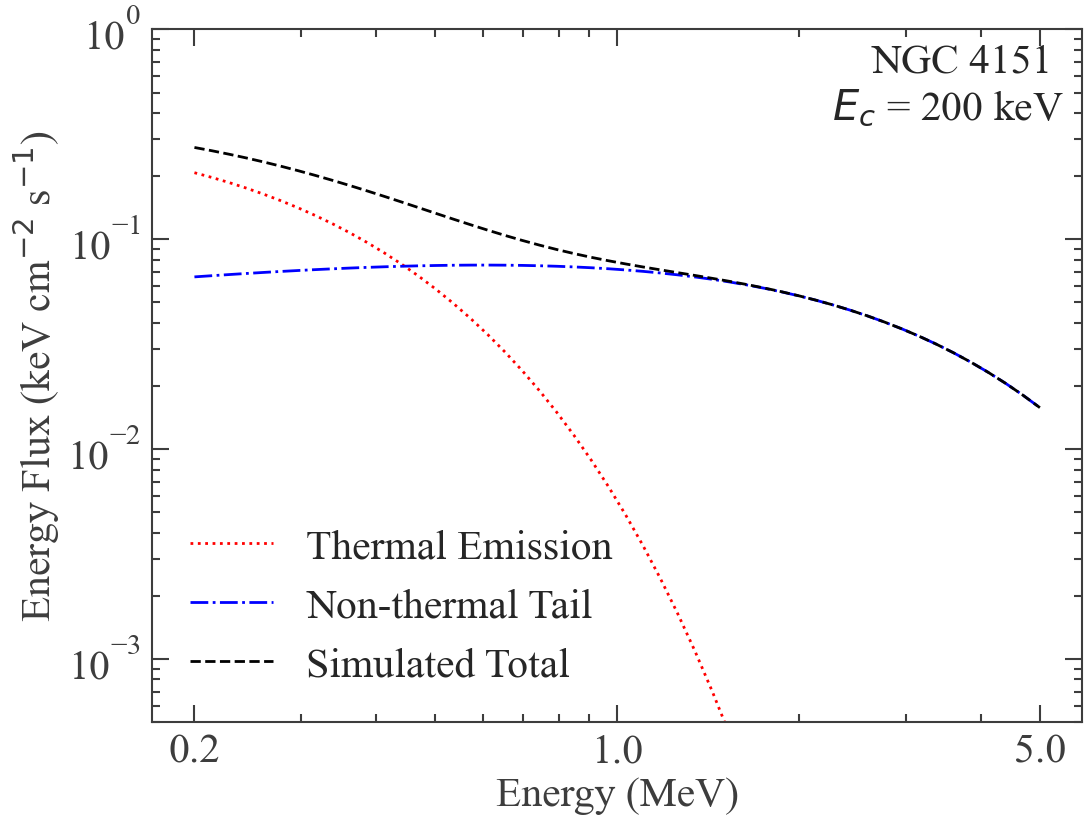

In [311]:
FONT_SIZE=30
plt.rcParams['agg.path.chunksize'] = 10000

plt.rcParams.update({'font.size': FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams.update({
    'font.weight': '550',
    'axes.titleweight': '550',
    'axes.labelweight': '550'
})

fig, ax = plt.subplots(figsize=(12, 9))

ax.xaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', top='on', pad=8, labelsize=FONT_SIZE)
ax.xaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', top='on', pad=8)
ax.yaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', right='on', pad=8, labelsize=FONT_SIZE)
ax.yaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', right='on', pad=8)

ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)

# 200 keV cutoff
text = 'NGC 4151 \n $E_{c}$ = 200 keV'
total_flux_ec200 = flux_inj_ec200 + flux_inj_ec200_PL
ax.plot(energy, energy*energy*flux_inj_ec200, color = 'red', ls = ":", label = "Thermal Emission")
ax.plot(energy, energy*energy*flux_inj_ec200_PL, color = 'blue', ls = "-.", label = "Non-thermal Tail")
ax.plot(energy, energy*energy*total_flux_ec200, color = 'black', ls = "--", label = "Simulated Total")
ax.set_ylim(5e-4, 1)
ax.text(
    0.98, 0.98,
    text,
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)
save_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC/Plots/NGC4151_TH_NTH_Testa_EC200.pdf"

# # # 1000 keV cutoff
# text = 'NGC 4151 \n $E_{c}$ = 1000 keV'
# total_flux_ec1000 = flux_inj_ec1000 + flux_inj_ec1000_PL
# ax.plot(energy, energy*energy*flux_inj_ec1000, color = 'red', ls = ":", label = "Thermal Emission")
# ax.plot(energy, energy*energy*flux_inj_ec1000_PL, color = 'blue', ls = "-.", label = "Non-thermal Tail")
# ax.plot(energy, energy*energy*total_flux_ec1000, color = 'black', ls = "--", label = "Simulated Total")
# ax.set_ylim(5e-3, 1)
# ax.text(
#     0.98, 0.98,
#     text,
#     transform=ax.transAxes,
#     ha='right', va='top',
#     fontsize=FONT_SIZE,
#     fontweight='550'
# )
# save_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC/Plots/NGC4151_TH_NTH_Testa_EC1000.pdf"

# # 200 keV cutoff in TeV
# text = 'NGC 4151 \n $E_{c}$ = 200 keV'
# total_flux_ec200 = flux_inj_ec200 + flux_inj_ec200_PL
# ax.plot(energy, energy*energy*flux_inj_ec200*(1e-9), color = 'red', ls = ":", label = "Thermal Emission")
# ax.plot(energy, energy*energy*flux_inj_ec200_PL*(1e-9), color = 'blue', ls = "-.", label = "Non-thermal Tail")
# ax.plot(energy, energy*energy*total_flux_ec200*(1e-9), color = 'black', ls = "--", label = "Simulated Total")
# ax.set_ylim(4e-14, 4e-7)
# ax.text(
#     0.98, 0.98,
#     text,
#     transform=ax.transAxes,
#     ha='right', va='top',
#     fontsize=FONT_SIZE,
#     fontweight='550'
# )
# save_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC/Plots/NGC4151_TH_NTH_Testa_EC200.pdf"

ax.set_xscale("log")
ax.set_yscale("log")

ax.xaxis.set_major_locator(mticker.FixedLocator([200, 1000, 5000]))
ax.xaxis.set_major_formatter(
    mticker.FixedFormatter(["0.2", "1.0", "5.0"])
)

ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.set_ylabel(r"Energy Flux (keV cm$^{-2}$ s$^{-1}$)", fontsize=FONT_SIZE)
# ax.set_ylabel(r"Energy Flux (TeV cm$^{-2}$ s$^{-1}$)", fontsize=FONT_SIZE)

ax.legend(fontsize=FONT_SIZE, loc='lower left', frameon=False)

# plt.savefig(save_path)

# Spectral Fitting

In [11]:
bat_rsp_ec200 = "/Users/parshadkp/Software/COSI_Data/AGN_Data/XRay/swiftbat_survey_full.rsp"
bat_pha_ec200 = "/Users/parshadkp/Software/COSI_Data/AGN_Data/XRay/SWIFT_J1210.5+3924_resp.pha"

bat_rsp_ec1000 = data_path/"AGN_Data/XRay/Simulations/BAT_157m_swiftbat_survey_full_157m.rsp"
bat_pha_ec1000 = data_path/"AGN_Data/XRay/Simulations/simulate_bat_ec_1000_gamma_1dot75.pha"

bat_ec200 = OGIPLike("BAT", observation=bat_pha_ec200, response=bat_rsp_ec200)
bat_ec1000 = OGIPLike("BAT", observation=bat_pha_ec1000, response=bat_rsp_ec1000)

bat_ec200.set_active_measurements("40-200")
bat_ec1000.set_active_measurements("40-200")

# bat_ec200.view_count_spectrum()
# bat_ec1000.view_count_spectrum()

20:58:24 INFO      Auto-probed noise models:                                                    ]8;id=811874;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=991879;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#486\486]8;;\

         INFO      - observation: gaussian                                                      ]8;id=338921;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=607182;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#487\487]8;;\

         INFO      - background: None                                                           ]8;id=210638;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=427740;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#488\488]8;;\

         INFO      Auto-probed noise models:                                                    ]8;id=490843;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=670312;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#486\486]8;;\

         INFO      - observation: gaussian                                                      ]8;id=313301;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=60629;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#487\487]8;;\

         INFO      - background: None                                                           ]8;id=632503;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=779875;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#488\488]8;;\

         INFO      Range 40-200 translates to channels 3-8                                     ]8;id=649854;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=330666;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#1237\1237]8;;\

         INFO      Range 40-200 translates to channels 3-8                                     ]8;id=167642;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=122756;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/plugins/SpectrumLike.py#1237\1237]8;;\

In [10]:
# NGC4151_ec200 = Histogram.open(data_path/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec200_DC3_COSI_cpl_cpl.hdf5")*multiplier_4151
# bkg = Histogram.open(data_path /  "DC4_Files/Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck_NGC4151_TimeCut.hdf5")*multiplier_4151
# NGC4151_ec200_bkg = Histogram.open(data_path/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec200_DC4_COSI_cpl_cpl_TimeCutBkg.hdf5")*multiplier_4151

NGC4151_ec200 = Histogram.open(data_path/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec200_DC3_COSI_cpl_cpl_HighEC_2000.hdf5")*multiplier_4151
bkg = Histogram.open(data_path /  "DC4_Files/Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck_NGC4151_TimeCut.hdf5")*multiplier_4151
NGC4151_ec200_bkg = Histogram.open(data_path/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec200_DC4_COSI_cpl_cpl_HighEC_2000_TimeCutBkg.hdf5")*multiplier_4151

# NGC4151_ec200_pl = Histogram.open(data_path/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec200_DC3_COSI_cpl_pl.hdf5")*multiplier_4151

# full_bkg = Histogram.open(data_path /  "DC4_Files/Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck.hdf5")*multiplier_4151

In [11]:
NGC4151_ec1000 = Histogram.open(data_path/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec1000_DC3_COSI_cpl_cpl.hdf5")*multiplier_4151
NGC4151_ec1000_bkg = Histogram.open(data_path/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec1000_DC4_COSI_cpl_cpl_TimeCutBkg.hdf5")*multiplier_4151

# NGC4151_ec1000 = Histogram.open(data_path/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec1000_DC3_COSI_cpl_cpl_HighEC_2000keV.hdf5")*multiplier_4151
# NGC4151_ec1000_bkg = Histogram.open(data_path/"AGN_Data/GammaRay/Paper_Models/NGC_4151_ec1000_DC4_COSI_cpl_cpl_HighEC_2000keV_TimeCutBkg.hdf5")*multiplier_4151

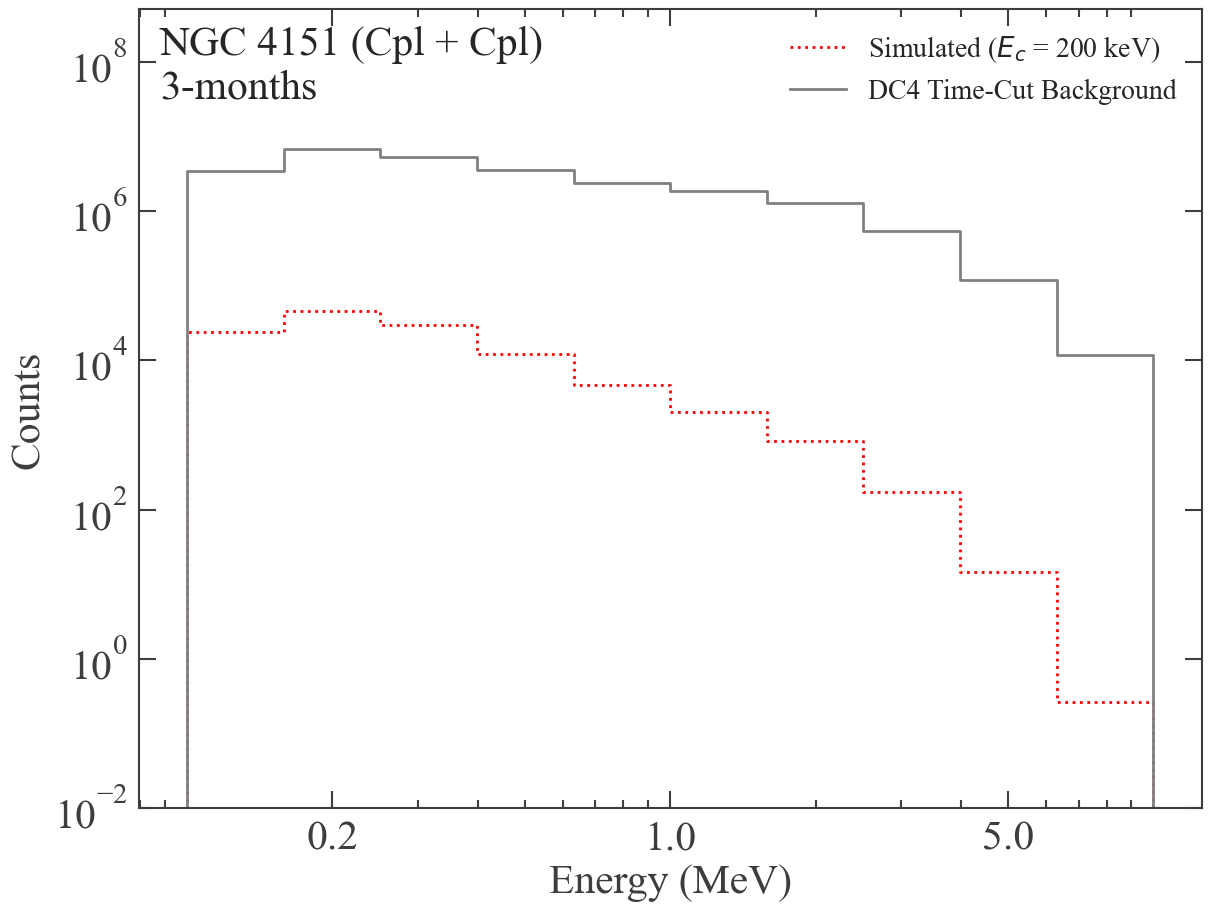

In [97]:
FONT_SIZE=30
plt.rcParams['agg.path.chunksize'] = 10000

plt.rcParams.update({'font.size': FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams.update({
    'font.weight': '550',
    'axes.titleweight': '550',
    'axes.labelweight': '550'
})

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)

ax.xaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', top='on', pad=8, labelsize=FONT_SIZE)
ax.xaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', top='on', pad=8)
ax.yaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', right='on', pad=8, labelsize=FONT_SIZE)
ax.yaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', right='on', pad=8)

ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)

NGC4151_ec200.project("Em").draw(ax, label="Simulated ($E_c$ = 200 keV)", color="red", linestyle="dotted")
# NGC4151_ec1000.project("Em").draw(ax, label="Simulated ($E_c$ = 1000 keV)", color="blue", linestyle="dotted")
bkg.project("Em").draw(ax, label="DC4 Time-Cut Background", color="grey")
# full_bkg.project("Em").draw(ax, label="DC4 Full Background", color="black", linestyle="dashdot")
# NGC4151_ec200_bkg.project("Em").draw(ax, label="NGC 4151 Model ($E_c$ = 200 keV) + Background", linestyle='dashdot', color="red")
# NGC4151_ec1000_bkg.project("Em").draw(ax, label="NGC 4151 Model ($E_c$ = 1000 keV) + Background", linestyle='dashdot', color="blue")

text = f'NGC 4151 (Cpl + Cpl) \n{exposure_4151}-months'
ax.text(
    0.02, 0.98,
    text,
    transform=ax.transAxes,
    ha='left', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)

ax.set_yscale("log")
ax.set_xscale("log")

ax.set_ylabel("Counts", fontsize=FONT_SIZE)
ax.set_ylim(1e-2, 5e8)

ax.xaxis.set_major_locator(mticker.FixedLocator([200, 1000, 5000]))
ax.xaxis.set_major_formatter(
    mticker.FixedFormatter(["0.2", "1.0", "5.0"])
)

ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.legend(fontsize=20, loc='upper right', frameon=False)

save_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC/Plots/NGC4151_Cpl_Cpl_Counts_200_3Months.pdf"
plt.savefig(save_path)

Define the path to the detector response

## Perform spectral fit

Set background parameter, which is used to fit the amplitude of the background, and instantiate the COSI 3ML plugin

In [12]:
from agn_cosi_fit_utils import COSIPlugin, EnergyRangeCOSIPlugin, make_cosi_background_parameter
bkg_par = Parameter("background_cosi",                                         # background parameter
                     1,                                                        # initial value of parameter
                     min_value=0,                                              # minimum value of parameter
                     max_value=5,                                              # maximum value of parameter
                     delta=0.05,                                               # initial step used by fitting engine
                     desc="Background parameter for cosi")

bkg_par_ec1000 = Parameter("background_cosi_ec1000",                           # background parameter
                     1,                                                        # initial value of parameter
                     min_value=0,                                              # minimum value of parameter
                     max_value=5,                                              # maximum value of parameter
                     delta=0.05,                                               # initial step used by fitting engine
                     desc="Background parameter for cosi")

cosi = COSIPlugin("cosi",                                                        # COSI 3ML plugin
                 dr = dr,                                                      # detector response
                 data = NGC4151_ec200_bkg.project('Em', 'Phi', 'PsiChi'),   # data (source+background)
                 bkg = bkg.project('Em', 'Phi', 'PsiChi'),         # background model 
                 sc_orientation = sc_orientation,                              # spacecraft orientation
                 nuisance_param = bkg_par,                                     # background parameter
                 earth_occ = True)                                             # Option to account for Earth occultation

cosi_ec1000 = COSIPlugin("cosi",                                                        # COSI 3ML plugin
                 dr = dr,                                                      # detector response
                 data = NGC4151_ec1000_bkg.project('Em', 'Phi', 'PsiChi'),   # data (source+background)
                 bkg = bkg.project('Em', 'Phi', 'PsiChi'),         # background model 
                 sc_orientation = sc_orientation,                              # spacecraft orientation
                 nuisance_param = bkg_par_ec1000,                                     # background parameter
                 earth_occ = True)                                             # Option to account for Earth occultation

### Powerlaw with energy cutoff fit

In [13]:
l=155.07
b=75.06

# Give it some harsher initial guesses
K = 1e-5 / u.cm / u.cm / u.s / u.keV
piv = 200. * u.keV
xc = 100. * u.keV
index = -1.75
# index = -1.71

spectrum_cpl = Cutoff_powerlaw()

spectrum_cpl.K.value = K.value
spectrum_cpl.piv.value = piv.value
spectrum_cpl.xc.value = xc.value
spectrum_cpl.index.value = index
spectrum_cpl.index.fix = True

# Harsher Parameters
spectrum_cpl.K.min_value = 1e-8
spectrum_cpl.K.max_value = 1e-2
spectrum_cpl.xc.min_value = 100 # keep these relatively the same
spectrum_cpl.xc.max_value = 10000 # change to 1000
# spectrum_cpl.index.min_value = -3 # change to -3.5 to sample lower, larger values (-5, 5)
# spectrum_cpl.index.max_value = 1

# spectrum_cpl.K.delta = 0.05
# spectrum_cpl.xc.delta = 10
# spectrum_cpl.index.delta = 0.15

spectrum_cpl.K.unit = K.unit
spectrum_cpl.piv.unit = piv.unit
spectrum_cpl.xc.unit = xc.unit

source1 = PointSource("source1",                     # Name of source (arbitrary, but needs to be unique)
                     l = l,                        # Longitude (deg)
                     b = b,                        # Latitude (deg)
                     spectral_shape = spectrum_cpl)    # Spectral model

In [14]:
l=155.07
b=75.06

# Give it some harsher initial guesses
K = 1e-5 / u.cm / u.cm / u.s / u.keV
piv = 200. * u.keV
xc = 1000. * u.keV
index = -1.75
# index = -1.81

spectrum_cpl_ec1000 = Cutoff_powerlaw()

spectrum_cpl_ec1000.K.value = K.value
spectrum_cpl_ec1000.piv.value = piv.value
spectrum_cpl_ec1000.xc.value = xc.value
spectrum_cpl_ec1000.index.value = index
spectrum_cpl_ec1000.index.fix = True

# Harsher Parameters
spectrum_cpl_ec1000.K.min_value = 1e-8
spectrum_cpl_ec1000.K.max_value = 1e-2
spectrum_cpl_ec1000.xc.min_value = 100 # keep these relatively the same
spectrum_cpl_ec1000.xc.max_value = 10000 # change to 1000
# spectrum_cpl_ec1000.index.min_value = -3 # change to -3.5 to sample lower, larger values (-5, 5)
# spectrum_cpl_ec1000.index.max_value = 1

# spectrum_cpl_ec1000.K.delta = 0.05
# spectrum_cpl_ec1000.xc.delta = 10
# spectrum_cpl_ec1000.index.delta = 0.15

spectrum_cpl_ec1000.K.unit = K.unit
spectrum_cpl_ec1000.piv.unit = piv.unit
spectrum_cpl_ec1000.xc.unit = xc.unit

source2 = PointSource("source2",                     # Name of source (arbitrary, but needs to be unique)
                     l = l,                        # Longitude (deg)
                     b = b,                        # Latitude (deg)
                     spectral_shape = spectrum_cpl_ec1000)    # Spectral model

## Thermal + Non-thermal Fit

In [15]:
l=155.07
b=75.06

# Give it some harsher initial guesses
K = 1e-5 / u.cm / u.cm / u.s / u.keV
piv = 200. * u.keV
xc = 1200. * u.keV
index = -1.7
# index = -1.71

spectrum = Cutoff_powerlaw()

spectrum.K.value = K.value
spectrum.piv.value = piv.value
spectrum.xc.value = xc.value
spectrum.index.value = index
# spectrum.index.fix = True

# Harsher Parameters
spectrum.K.min_value = 1e-8
spectrum.K.max_value = 1e-2
spectrum.xc.min_value = 1000 # keep these relatively the same
spectrum.xc.max_value = 10000 # change to 1000
spectrum.index.min_value = -3 # change to -3.5 to sample lower, larger values (-5, 5)
spectrum.index.max_value = 1

# spectrum_cpl.K.delta = 0.05
# spectrum_cpl.xc.delta = 10
# spectrum_cpl.index.delta = 0.15

spectrum.K.unit = K.unit
spectrum.piv.unit = piv.unit
spectrum.xc.unit = xc.unit

source3 = PointSource("source3",                     # Name of source (arbitrary, but needs to be unique)
                     l = l,                        # Longitude (deg)
                     b = b,                        # Latitude (deg)
                     spectral_shape = spectrum)    # Spectral model

In [16]:
l=155.07
b=75.06

# Give it some harsher initial guesses
K = 1e-5 / u.cm / u.cm / u.s / u.keV
piv = 200. * u.keV
xc = 1500. * u.keV
index = -1.7
# index = -1.71

spectrum_ec1000 = Cutoff_powerlaw()

spectrum_ec1000.K.value = K.value
spectrum_ec1000.piv.value = piv.value
spectrum_ec1000.xc.value = xc.value
spectrum_ec1000.index.value = index
# spectrum_ec1000.index.fix = True

# Harsher Parameters
spectrum_ec1000.K.min_value = 1e-8
spectrum_ec1000.K.max_value = 1e-2
spectrum_ec1000.xc.min_value = 1000 # keep these relatively the same
spectrum_ec1000.xc.max_value = 10000 # change to 1000
spectrum_ec1000.index.min_value = -3 # change to -3.5 to sample lower, larger values (-5, 5)
spectrum_ec1000.index.max_value = 1

# spectrum_cpl.K.delta = 0.05
# spectrum_cpl.xc.delta = 10
# spectrum_cpl.index.delta = 0.15

spectrum_ec1000.K.unit = K.unit
spectrum_ec1000.piv.unit = piv.unit
spectrum_ec1000.xc.unit = xc.unit

source4 = PointSource("source4",                     # Name of source (arbitrary, but needs to be unique)
                     l = l,                        # Longitude (deg)
                     b = b,                        # Latitude (deg)
                     spectral_shape = spectrum_ec1000)    # Spectral model

In [17]:
model = Model(source1, source3)  # Model with single source. If we had multiple sources, we would do Model(source1, source2, ...)
model_ec1000 = Model(source2, source4)  # Model with single source. If we had multiple sources, we would do Model(source1, source2, ...)

cosi.set_model(model)
cosi_ec1000.set_model(model_ec1000)

### Joint Fit

In [ ]:
# bat_ec200.use_effective_area_correction(0.02, 1.8)
# plugins = DataList(bat_ec200, cosi)

# bat_ec1000.use_effective_area_correction(0.02, 1.8)
# plugins_ec1000 = DataList(bat_ec1000, cosi_ec1000)

### Only COSI Fit

In [18]:
## Only COSI fit
plugins = DataList(cosi)
plugins_ec1000 = DataList(cosi_ec1000)

### Normal Case

In [20]:
ratio_ec200 = linking_ratio_ec200
link_function = Line(a=0.0, b=ratio_ec200)   # source3.K = a + b * source1.K
link_function.a.fix = True
# link_function.b.fix = True             # keep ratio fixed at

ratio_ec1000 = linking_ratio_ec1000
link_function_ec1000 = Line(a=0.0, b=ratio_ec1000)   # source4.K = a + b * source2.K
link_function_ec1000.a.fix = True
# link_function_ec1000.b.fix = True             # keep ratio fixed

model.link(
    model.source3.spectrum.main.Cutoff_powerlaw.K,         # dependent
    model.source1.spectrum.main.Cutoff_powerlaw.K,  # independent
    link_function,
)
model_ec1000.link(
    model_ec1000.source4.spectrum.main.Cutoff_powerlaw.K,         # dependent
    model_ec1000.source2.spectrum.main.Cutoff_powerlaw.K,  # independent
    link_function_ec1000,
)

like = JointLikelihood(model, plugins, verbose = False)
like_ec1000 = JointLikelihood(model_ec1000, plugins_ec1000, verbose = False)

result = like.fit()
result_ec1000 = like_ec1000.fit()

23:47:40 INFO      set the minimizer to minuit                                             ]8;id=322807;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=611918;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=128434;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=432764;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

Adding 1e-12 to each bin of the expectation to avoid log-likelihood = -inf.

WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log



Best fit values:

,result,unit
parameter,,
source1.spectrum.main.Cutoff_powerlaw.K,(1.39 -0.26 +0.32) x 10^-5,1 / (keV s cm2)
source1.spectrum.main.Cutoff_powerlaw.xc,(2.08 -0.30 +0.35) x 10^2,keV
source3.spectrum.main.Cutoff_powerlaw.K.Line.b,(1.2 +/- 1.2) x 10^-1,
source3.spectrum.main.Cutoff_powerlaw.index,-1.7 +/- 0.7,
source3.spectrum.main.Cutoff_powerlaw.xc,(2.4 -1.9 +8) x 10^3,keV
background_cosi,1.00000 +/- 0.00028,


...

1.00,-0.38,-0.94,0.15,0.32,-0.05
-0.38,1.00,0.22,-0.27,-0.82,0.03
-0.94,0.22,1.00,0.06,-0.32,0.03
0.15,-0.27,0.06,1.00,-0.30,0.26
0.32,-0.82,-0.32,-0.30,1.00,-0.22
-0.05,0.03,0.03,0.26,-0.22,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-1.130424e+08
total,-1.130424e+08


Values of statistical measures:

,statistical measures
AIC,-2.260849e+08
BIC,-2.260849e+08


In [21]:
from agn_cosi_fit_utils import COSIPlugin, EnergyRangeCOSIPlugin, make_cosi_background_parameter
def make_null_likelihood(data_hist):
    cosi_null = COSIPlugin("cosi",                                                # COSI 3ML plugin
                     dr = dr,                                                    # detector response
                     data = data_hist.project('Em', 'Phi', 'PsiChi'),            # data (source+background)
                     bkg = bkg.project('Em', 'Phi', 'PsiChi'),                   # background model
                     sc_orientation = sc_orientation,                            # spacecraft orientation
                     nuisance_param = bkg_par,                                   # background parameter
                     earth_occ = True)                                           # Match the source fits

    spectrum_null = Powerlaw()
    spectrum_null.K.value = 1e-30
    spectrum_null.index.value = 1
    spectrum_null.K.fix = True
    spectrum_null.index.fix = True

    source_null = PointSource(
        "source_null",
        l=l,
        b=b,
        spectral_shape=spectrum_null,
    )

    model_null = Model(source_null)
    cosi_null.set_model(model_null)

    plugins_null = DataList(cosi_null)
    like_null = JointLikelihood(model_null, plugins_null, verbose=False)
    like_null.fit()

    return like_null

like_null_200 = make_null_likelihood(NGC4151_ec200_bkg)
like_null_1000 = make_null_likelihood(NGC4151_ec1000_bkg)

TS = 2 * (
    like_null_200.results.get_statistic_frame()["-log(likelihood)"]["cosi"]
    - like.results.get_statistic_frame()["-log(likelihood)"]["cosi"]
)

TS_ec1000 = 2 * (
    like_null_1000.results.get_statistic_frame()["-log(likelihood)"]["cosi"]
    - like_ec1000.results.get_statistic_frame()["-log(likelihood)"]["cosi"]
)

print("L1", -like.results.get_statistic_frame()["-log(likelihood)"]["cosi"])
print("L0", -like_null_200.results.get_statistic_frame()["-log(likelihood)"]["cosi"])
print("TS Value: ", TS)
print("Significance [200 keV]: ", np.sqrt(TS))

print("L1", -like_ec1000.results.get_statistic_frame()["-log(likelihood)"]["cosi"])
print("L0", -like_null_1000.results.get_statistic_frame()["-log(likelihood)"]["cosi"])
print("TS Value: ", TS_ec1000)
print("Significance [1000 keV]: ", np.sqrt(TS_ec1000))

23:50:50 INFO      set the minimizer to minuit                                             ]8;id=512513;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=3582;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

Adding 1e-12 to each bin of the expectation to avoid log-likelihood = -inf.


Best fit values:

,result,unit
parameter,,
background_cosi,1.00470 +/- 0.00020,


Correlation matrix:

...

Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-1.130405e+08
total,-1.130405e+08


Values of statistical measures:

,statistical measures
AIC,-2.260809e+08
BIC,-2.260809e+08


L1 112086273.69695495
L0 112085894.79274029
TS Value:  757.8084293305874
Significance [200 keV]:  27.5283204960017
L1 113042435.14939983
L0 113040466.44719139
TS Value:  3937.4044168889523
Significance [1000 keV]:  62.748740360974196


In [22]:
results = like.results
results_ec1000 = like_ec1000.results
results_sed = results
results_sed_ec1000 = results_ec1000
data_sed_hist = cosi._data.copy()
bkg_sed_hist = cosi._bkg_hist.copy()
data_sed_ec1000_hist = cosi_ec1000._data.copy()
bkg_sed_ec1000_hist = cosi_ec1000._bkg_hist.copy()

print(results.display())

# Collect parameters from BOTH sources
parameters_source1 = {
    par.name: results.get_variates(par.path)
    for par in results.optimized_model["source1"].parameters.values()
    if par.free
}

parameters_source3 = {
    par.name: results.get_variates(par.path)
    for par in results.optimized_model["source3"].parameters.values()
    if par.free
}

# Collect parameters from BOTH sources
parameters_source2_ec1000 = {
    par.name: results_ec1000.get_variates(par.path)
    for par in results_ec1000.optimized_model["source2"].parameters.values()
    if par.free
}

parameters_source4_ec1000 = {
    par.name: results_ec1000.get_variates(par.path)
    for par in results_ec1000.optimized_model["source4"].parameters.values()
    if par.free
}

# Propagate errors for each source separately
results_err_source1 = results.propagate(
    results.optimized_model["source1"].spectrum.main.shape.evaluate_at,
    **parameters_source1
)

results_err_source3 = results.propagate(
    results.optimized_model["source3"].spectrum.main.shape.evaluate_at,
    **parameters_source3
)

# Propagate errors for each source separately
results_err_source2_ec1000 = results_ec1000.propagate(
    results_ec1000.optimized_model["source2"].spectrum.main.shape.evaluate_at,
    **parameters_source2_ec1000
)

results_err_source4_ec1000 = results_ec1000.propagate(
    results_ec1000.optimized_model["source4"].spectrum.main.shape.evaluate_at,
    **parameters_source4_ec1000
)

# Print both sources
# print("\n=== Source 1 (Cutoff Power Law) ===")
# print(results.optimized_model["source1"])
# print("\n=== Source 2 (Power Law) ===")
# print(results.optimized_model["source2"])

Best fit values:

,result,unit
parameter,,
source1.spectrum.main.Cutoff_powerlaw.K,(1.39 -0.26 +0.32) x 10^-5,1 / (keV s cm2)
source1.spectrum.main.Cutoff_powerlaw.xc,(2.08 -0.30 +0.35) x 10^2,keV
source3.spectrum.main.Cutoff_powerlaw.K.Line.b,(1.2 +/- 1.2) x 10^-1,
source3.spectrum.main.Cutoff_powerlaw.index,-1.7 +/- 0.7,
source3.spectrum.main.Cutoff_powerlaw.xc,(2.4 -1.9 +8) x 10^3,keV
background_cosi,1.00000 +/- 0.00028,


Correlation matrix:

1.00,0.02,-0.83,0.86,-0.40,-0.19
0.02,1.00,-0.55,0.21,0.28,-0.05
-0.83,-0.55,1.00,-0.81,0.13,0.12
0.86,0.21,-0.81,1.00,-0.65,-0.08
-0.40,0.28,0.13,-0.65,1.00,-0.13
-0.19,-0.05,0.12,-0.08,-0.13,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-1.120863e+08
total,-1.120863e+08


Values of statistical measures:

,statistical measures
AIC,-2.241725e+08
BIC,-2.241725e+08


None


In [23]:
energy = np.geomspace(200*u.keV,5*u.MeV).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)

flux_lo_ec1000 = np.zeros_like(energy)
flux_median_ec1000 = np.zeros_like(energy)
flux_hi_ec1000 = np.zeros_like(energy)
flux_inj_ec1000 = np.zeros_like(energy)

# Add arrays for individual components
flux_median_source1 = np.zeros_like(energy)
flux_median_source3 = np.zeros_like(energy)

flux_median_source2_ec1000 = np.zeros_like(energy)
flux_median_source4_ec1000 = np.zeros_like(energy)

for i, e in enumerate(energy):
    # Evaluate each source separately
    flux1 = results_err_source1(e)
    flux2 = results_err_source3(e)

    flux1_ec1000 = results_err_source2_ec1000(e)
    flux2_ec1000 = results_err_source4_ec1000(e)

    # Store individual components
    flux_median_source1[i] = flux1.median
    flux_median_source3[i] = flux2.median
    flux_median_source2_ec1000[i] = flux1_ec1000.median
    flux_median_source4_ec1000[i] = flux2_ec1000.median

    # Add the RandomVariates directly
    flux_combined = flux1 + flux2
    flux_combined_ec1000 = flux1_ec1000 + flux2_ec1000
    
    # Get median and intervals from the combined distribution
    flux_median[i] = flux_combined.median
    flux_lo[i], flux_hi[i] = flux_combined.equal_tail_interval(cl=0.68)

    flux_median_ec1000[i] = flux_combined_ec1000.median
    flux_lo_ec1000[i], flux_hi_ec1000[i] = flux_combined_ec1000.equal_tail_interval(cl=0.68)
    
    flux_inj[i] = spectrum_inj_ec200_total.evaluate_at(e)
    flux_inj_ec1000[i] = spectrum_inj_ec1000_total.evaluate_at(e)

binned_energy_edges = NGC4151_ec200.axes['Em'].edges.value
binned_energy = np.array([])
bin_sizes = np.array([])
binned_energy_ec1000 = np.array([])

for i in range(len(binned_energy_edges)-1):
    binned_energy = np.append(binned_energy, (binned_energy_edges[i+1] + binned_energy_edges[i]) / 2)
    bin_sizes = np.append(bin_sizes, binned_energy_edges[i+1] - binned_energy_edges[i])
    
    binned_energy_ec1000 = np.append(binned_energy_ec1000, (binned_energy_edges[i+1] + binned_energy_edges[i]) / 2)


expectation = cosi._expected_counts['source1'] + cosi._expected_counts['source3']
expectation = cosi_ec1000._expected_counts['source2'] + cosi_ec1000._expected_counts['source4']


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'


WARNING SyntaxWarning: invalid escape sequence '\s'



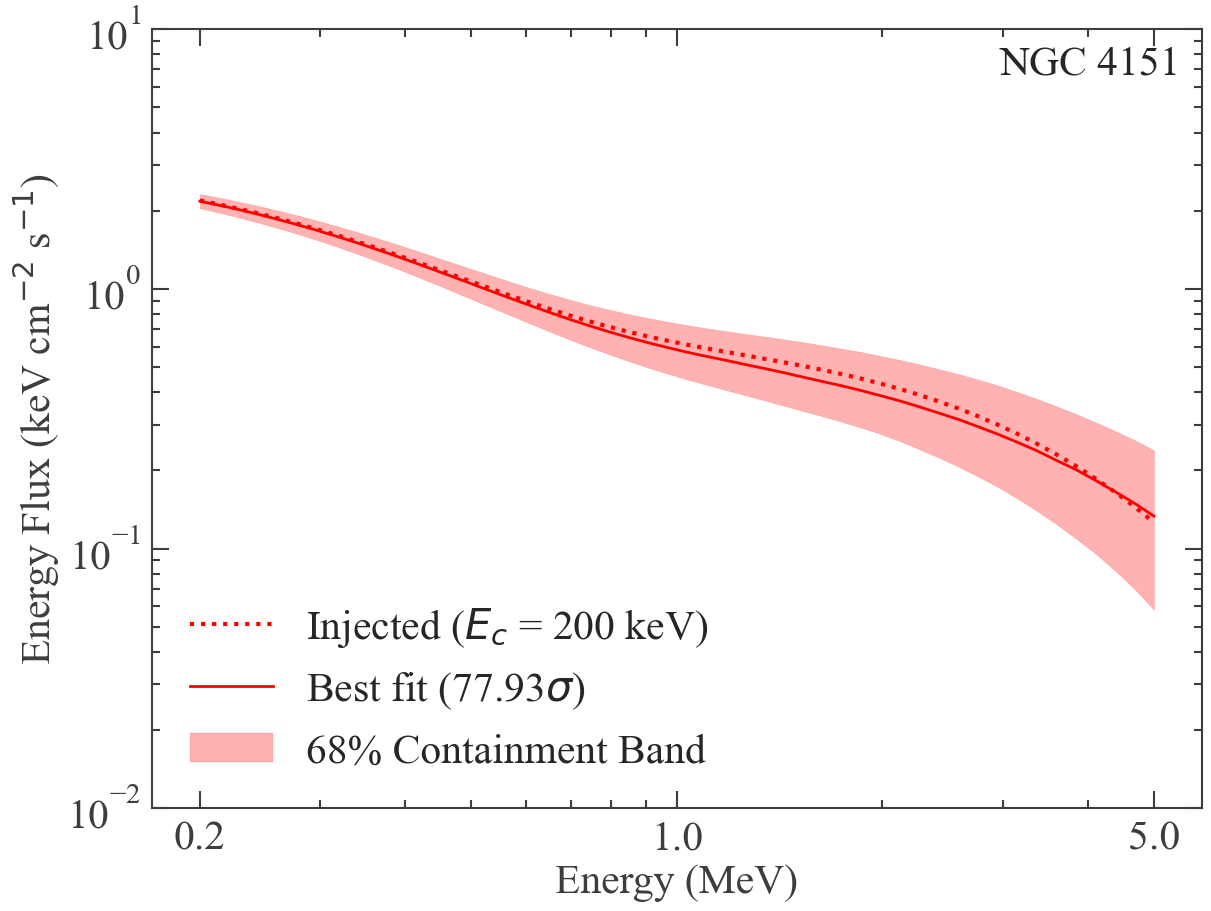

In [77]:
FONT_SIZE=30
plt.rcParams['agg.path.chunksize'] = 10000

plt.rcParams.update({'font.size': FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams.update({
    'font.weight': '550',
    'axes.titleweight': '550',
    'axes.labelweight': '550'
})

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)

ax.xaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', top='on', pad=8, labelsize=FONT_SIZE)
ax.xaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', top='on', pad=8)
ax.yaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', right='on', pad=8, labelsize=FONT_SIZE)
ax.yaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', right='on', pad=8)

ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)

Sigma = np.sqrt(TS)
Sigma_ec1000 = np.sqrt(TS_ec1000)

# # NGC 4151
text = f'NGC 4151'

# Plot individual components
# ax.plot(energy, energy*energy*flux_median_source1, label = "Cutoff PL", color = 'red', ls='--', alpha=0.7)
# ax.plot(energy, energy*energy*flux_median_source3, label = "Power Law", color = 'red', ls='-.', alpha=0.7)
# Total component
ax.plot(energy, energy*energy*flux_inj, color = 'red', ls = ":", lw=3, label = "Injected ($E_c$ = 200 keV)")
ax.plot(energy, energy*energy*flux_median, color = 'red', label = f"Best fit ({Sigma:.2f}$\sigma$)")
ax.fill_between(energy, energy*energy*flux_lo, energy*energy*flux_hi, alpha = .3, color = 'red', label = "68% Containment Band")

# Plot individual components
# ax.plot(energy, energy*energy*flux_median_source2_ec1000, label = "Cutoff PL", color = 'blue', ls='--', alpha=0.7)
# ax.plot(energy, energy*energy*flux_median_source4_ec1000, label = "Power Law", color = 'blue', ls='-.', alpha=0.7)
# Total component
# ax.plot(energy, energy*energy*flux_inj_ec1000, color = 'blue', ls = ":", lw=3, label = "Injected ($E_c$ = 1000 keV)")
# ax.plot(energy, energy*energy*flux_median_ec1000, color = 'blue', label = f"Best fit ({Sigma_ec1000:.2f}$\sigma)$")
# ax.fill_between(energy, energy*energy*flux_lo_ec1000, energy*energy*flux_hi_ec1000, alpha = .3, color='blue', label = "68% Containment Band")

ax.text(
    0.98, 0.98,
    text,
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)
save_path = f"/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC/Plots/NGC4151_Cpl_Pl_Fit_200_1000_{exposure_4151}Months_FrozenIndex.pdf"

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_ylim(1e-2, 10)

ax.xaxis.set_major_locator(mticker.FixedLocator([200, 1000, 5000]))
ax.xaxis.set_major_formatter(
    mticker.FixedFormatter(["0.2", "1.0", "5.0"])
)

ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.set_ylabel(r"Energy Flux (keV cm$^{-2}$ s$^{-1}$)", fontsize=FONT_SIZE)

ax.legend(fontsize=FONT_SIZE, loc='lower left', frameon=False)

# plt.savefig(save_path)

## SED

This extracts a bin-by-bin SED from the COSI fit. The photon index is frozen to the global-fit value in every bin. Because a single measured-energy band will not constrain the cutoff reliably, the helper below also fixes `xc` to the global-fit value. By default the COSI background nuisance parameter is left free, which matches the earlier working bin-by-bin behavior. You can optionally freeze it to a chosen reference value if you want a stricter one-parameter SED extraction. The helper also records whether a bin lands on the `K` lower bound, and if requested it can relax that lower bound and retry once before evaluating profile errors. You can also pass a stricter Minuit `ftol` to make the per-bin fits converge more tightly before MINOS is evaluated. If a manual fallback profile finds only an upper crossing, you can either keep that bin as an upper limit or convert it into a lower-bound-to-upper-crossing interval for plotting.


In [24]:
from agn_cosi_fit_utils import COSIPlugin, EnergyRangeCOSIPlugin, make_cosi_background_parameter
def _iter_model_sources(model):
    return [
        (name, child)
        for name, child in getattr(model, '_children', {}).items()
        if hasattr(child, 'spectrum')
    ]


def _get_source_spectral_shape(source, shape_name='Cutoff_powerlaw'):
    main_component = source.spectrum.main

    try:
        return getattr(main_component, shape_name)
    except AttributeError:
        shape = getattr(main_component, 'shape', None)
        if shape is not None and shape.__class__.__name__ == shape_name:
            return shape

    return None


def _resolve_source_name(model, source_name=None, shape_name='Cutoff_powerlaw'):
    sources = _iter_model_sources(model)

    if source_name is not None:
        source_names = [name for name, _ in sources]
        if source_name not in source_names:
            raise ValueError(f'Source {source_name!r} is not in optimized model. Available sources: {source_names}.')

        source = model[source_name]
        if _get_source_spectral_shape(source, shape_name=shape_name) is None:
            raise ValueError(f'Source {source_name!r} does not contain a {shape_name} shape.')

        return source_name

    source_names = [
        name
        for name, source in sources
        if _get_source_spectral_shape(source, shape_name=shape_name) is not None
    ]

    if len(source_names) != 1:
        raise ValueError(
            f'Expected one source with a {shape_name} shape, found {source_names}. '
            'Pass source_name to select the SED target explicitly.'
        )

    return source_names[0]


def _get_cutoff_powerlaw_shape(global_results, source_name=None):
    optimized_model = global_results.optimized_model
    source_name = _resolve_source_name(optimized_model, source_name=source_name)

    return _get_source_spectral_shape(optimized_model[source_name]), source_name


def build_thermal_sed_model(global_results, freeze_cutoff=True, source_name=None, freeze_non_target_parameters=True):
    from astromodels import clone_model

    best_fit_shape, source_name = _get_cutoff_powerlaw_shape(global_results, source_name=source_name)
    sed_model = clone_model(global_results.optimized_model)
    fit_shape = _get_source_spectral_shape(sed_model[source_name])

    if freeze_non_target_parameters:
        for parameter in sed_model.parameters.values():
            parameter.fix = True

    fit_shape.K.value = best_fit_shape.K.value
    fit_shape.K.min_value = max(best_fit_shape.K.value * 1e-3, 1e-12)
    fit_shape.K.max_value = best_fit_shape.K.value * 1e3
    fit_shape.K.fix = False
    fit_shape.index.value = best_fit_shape.index.value
    fit_shape.index.fix = True
    fit_shape.xc.value = best_fit_shape.xc.value
    fit_shape.xc.fix = freeze_cutoff

    return sed_model


def _hist_sum(hist):
    contents = hist.contents
    if hasattr(contents, 'todense'):
        contents = contents.todense()
    if hasattr(contents, 'value'):
        contents = contents.value
    return float(np.asarray(contents).sum())


def _evaluate_model_photon_flux(model, energy):
    photon_flux = 0.0

    for _, source in _iter_model_sources(model):
        photon_flux += float(source.spectrum.main.shape.evaluate_at(energy))

    return photon_flux


def _with_target_k_value(model, source_name, k_value, evaluator):
    target_shape = _get_source_spectral_shape(model[source_name])
    original_k = target_shape.K.value
    target_shape.K.value = float(k_value)

    try:
        return evaluator()
    finally:
        target_shape.K.value = original_k


def _integrate_model_energy_flux(model, source_name, k_value, e_min, e_max, n_points=256):
    energy_grid = np.geomspace(e_min, e_max, n_points)

    def evaluator():
        return np.asarray([_evaluate_model_photon_flux(model, energy) for energy in energy_grid])

    photon_flux = _with_target_k_value(model, source_name, k_value, evaluator)
    trapezoid = getattr(np, 'trapezoid', None)
    if trapezoid is None:
        trapezoid = np.trapz
    return float(trapezoid(energy_grid * photon_flux, energy_grid))


def _evaluate_model_sed_flux(model, source_name, k_value, energy):
    return _with_target_k_value(
        model,
        source_name,
        k_value,
        lambda: float(energy**2 * _evaluate_model_photon_flux(model, energy)),
    )


def _extract_profile_error(errors, suffix):
    if hasattr(errors, 'index'):
        for parameter_path in errors.index:
            if str(parameter_path).endswith(suffix):
                row = errors.loc[parameter_path]
                return float(row['negative_error']), float(row['positive_error'])
        return None

    for parameter_path, interval in errors.items():
        if str(parameter_path).endswith(suffix):
            return interval
    return None


def _get_global_background_scale(global_results, default=1.0):
    try:
        results_frame = global_results.get_data_frame()
    except Exception:
        return float(default)

    for parameter_path in results_frame.index:
        if str(parameter_path).startswith('background_'):
            return float(results_frame.loc[parameter_path, 'value'])

    return float(default)


def _run_joint_likelihood_fit(joint_likelihood):
    fit_status = 'covariance'
    try:
        joint_likelihood.fit(quiet=True)
    except Exception as exc:
        fit_status = f'no-covariance fallback ({type(exc).__name__})'
        joint_likelihood.fit(quiet=True, compute_covariance=False)
    return fit_status


def _get_joint_likelihood_statistic(joint_likelihood):
    statistic_frame = joint_likelihood.results.get_statistic_frame()

    if '-log(likelihood)' in statistic_frame.columns:
        statistic_column = statistic_frame['-log(likelihood)']
    else:
        numeric_frame = statistic_frame.select_dtypes(include=[np.number])
        if numeric_frame.empty:
            raise ValueError(f'No numeric statistic columns found in {list(statistic_frame.columns)}.')
        statistic_column = numeric_frame.iloc[:, 0]

    if 'total' in statistic_column.index:
        return float(statistic_column.loc['total'])

    return float(statistic_column.sum())


def _ts_to_sigma(ts_value):
    if not np.isfinite(ts_value) or ts_value <= 0:
        return 0.0

    return float(np.sqrt(ts_value))


def _build_null_sed_model(
    global_results,
    source_name,
    freeze_cutoff=True,
    freeze_non_target_parameters=True,
    null_k_value=1e-30,
):
    null_model = build_thermal_sed_model(
        global_results,
        freeze_cutoff=freeze_cutoff,
        source_name=source_name,
        freeze_non_target_parameters=freeze_non_target_parameters,
    )
    null_shape = _get_source_spectral_shape(null_model[source_name])
    null_k_value = max(float(null_k_value), np.finfo(float).tiny)
    null_k_min = max(null_k_value * 0.1, np.finfo(float).tiny)
    null_shape.K.min_value = min(float(null_shape.K.min_value or null_k_min), null_k_min)
    null_shape.K.value = null_k_value
    null_shape.K.fix = True

    return null_model


def _make_minuit_with_ftol(minuit_ftol):
    if minuit_ftol is None:
        return None

    minuit = LocalMinimization('minuit')
    minuit.setup(ftol=float(minuit_ftol))

    return minuit


def _hits_lower_bound(value, lower_bound):
    if lower_bound is None or not np.isfinite(lower_bound):
        return False

    atol = max(1e-18, abs(float(lower_bound)) * 1e-6)
    return bool(np.isclose(float(value), float(lower_bound), rtol=1e-3, atol=atol))


def _interpolate_profile_crossing(x1, y1, x2, y2, target):
    if np.isclose(y1, y2):
        return float(0.5 * (x1 + x2))

    fraction = float((target - y1) / (y2 - y1))
    fraction = float(np.clip(fraction, 0.0, 1.0))

    if x1 > 0 and x2 > 0:
        return float(np.exp(np.log(x1) + fraction * (np.log(x2) - np.log(x1))))

    return float(x1 + fraction * (x2 - x1))


def _find_profile_crossing(x_values, delta_ts, threshold, side):
    if len(x_values) == 0:
        return None

    minimum_index = int(np.nanargmin(delta_ts))

    if side == 'left':
        for index in range(minimum_index - 1, -1, -1):
            y1 = float(delta_ts[index])
            y2 = float(delta_ts[index + 1])
            if np.isnan(y1) or np.isnan(y2):
                continue
            if np.isclose(y1, threshold):
                return float(x_values[index])
            if (y1 - threshold) * (y2 - threshold) <= 0:
                return _interpolate_profile_crossing(
                    float(x_values[index]),
                    y1,
                    float(x_values[index + 1]),
                    y2,
                    threshold,
                )
        return None

    for index in range(minimum_index, len(x_values) - 1):
        y1 = float(delta_ts[index])
        y2 = float(delta_ts[index + 1])
        if np.isnan(y1) or np.isnan(y2):
            continue
        if np.isclose(y2, threshold):
            return float(x_values[index + 1])
        if (y1 - threshold) * (y2 - threshold) <= 0:
            return _interpolate_profile_crossing(
                float(x_values[index]),
                y1,
                float(x_values[index + 1]),
                y2,
                threshold,
            )

    return None


def _manual_k_profile_interval(
    joint_likelihood,
    parameter_path,
    center_value,
    lower_bound,
    upper_bound,
    n_steps=61,
    target_delta_ts=1.0,
    max_expansions=12,
    scan_expand_factor=1e2,
):
    if center_value <= 0:
        raise ValueError('Manual K profiling requires a positive best-fit normalization.')

    tiny_positive = float(np.finfo(float).tiny)
    scan_min = max(float(lower_bound), tiny_positive)
    scan_max = float(upper_bound) if np.isfinite(upper_bound) else float(center_value) * 1e6

    if not np.isfinite(scan_max) or scan_max <= scan_min:
        raise ValueError('Invalid K scan bounds for manual profiling.')

    import matplotlib.pyplot as plt

    left_crossing = None
    right_crossing = None

    for _ in range(max_expansions + 1):
        x_values, _, profile_values, profile_figure = joint_likelihood.get_contours(
            parameter_path,
            param_1_minimum=float(scan_min),
            param_1_maximum=float(scan_max),
            param_1_n_steps=int(n_steps),
            progress=False,
            log=(True,),
        )
        plt.close(profile_figure)

        x_values = np.asarray(x_values, dtype=float)
        profile_values = np.asarray(profile_values, dtype=float)
        delta_ts = 2.0 * (profile_values - np.nanmin(profile_values))
        minimum_index = int(np.nanargmin(delta_ts))

        left_crossing = _find_profile_crossing(x_values, delta_ts, target_delta_ts, 'left')
        right_crossing = _find_profile_crossing(x_values, delta_ts, target_delta_ts, 'right')

        if left_crossing is not None and right_crossing is not None:
            status = f'manual K profile ok ({len(x_values)} points, {scan_min:.3e}-{scan_max:.3e})'
            return float(left_crossing), float(right_crossing), status

        expanded = False

        if left_crossing is None and minimum_index > 0 and delta_ts[0] < target_delta_ts and scan_min > lower_bound:
            new_scan_min = max(float(lower_bound), float(scan_min) / scan_expand_factor)
            if new_scan_min < scan_min:
                scan_min = new_scan_min
                expanded = True

        if right_crossing is None and minimum_index < (len(x_values) - 1) and delta_ts[-1] < target_delta_ts and scan_max < upper_bound:
            new_scan_max = min(float(upper_bound), float(scan_max) * scan_expand_factor)
            if new_scan_max > scan_max:
                scan_max = new_scan_max
                expanded = True

        if not expanded:
            break

    status = f'manual K profile incomplete ({len(x_values)} points, {scan_min:.3e}-{scan_max:.3e})'
    return left_crossing, right_crossing, status


def fit_thermal_cosi_sed(
    global_results,
    data_hist,
    bkg_hist,
    dr_path,
    sc_orientation,
    source_name=None,
    n_sed_bins=5,
    freeze_cutoff=True,
    freeze_non_target_parameters=True,
    freeze_background=False,
    background_scale_value=None,
    minuit_ftol=None,
    error_estimation='minos_then_manual',
    manual_k_profile_points=61,
    manual_one_sided_mode='upper_limit',
    relax_k_lower_bound=True,
    energy_min_keV=200,
    energy_max_keV=5000,
    scan_expand_factor=1e2,
):
    threeML_config.point_source.integrate_flux_method = 'trapz'

    em_edges = data_hist.axes['Em'].edges.to_value(u.keV)
    native_em_bins = np.flatnonzero(
        (em_edges[:-1] >= energy_min_keV) & (em_edges[1:] <= energy_max_keV)
    )

    if len(native_em_bins) == 0:
        raise ValueError(
            f'No native Em bins are fully contained in {energy_min_keV}-{energy_max_keV} keV.'
        )

    def _split_last_group_remainder(arr, n_groups):
        arr = np.asarray(arr)
        if len(arr) < n_groups:
            raise ValueError(f"Need at least {n_groups} native bins, got {len(arr)}.")

        sizes = [1] * (n_groups - 1)
        sizes.append(len(arr) - (n_groups - 1))

        groups = []
        start = 0
        for size in sizes:
            groups.append(arr[start:start + size])
            start += size

        return groups

    grouped_bins = _split_last_group_remainder(native_em_bins, n_sed_bins)

    sed_rows = []
    best_fit_shape, source_name = _get_cutoff_powerlaw_shape(global_results, source_name=source_name)
    frozen_index = best_fit_shape.index.value
    frozen_cutoff = best_fit_shape.xc.value
    global_k = float(best_fit_shape.K.value)
    global_background_scale = _get_global_background_scale(global_results, default=1.0)

    if background_scale_value is not None:
        background_scale_value = float(background_scale_value)

    for sed_bin_index, group in enumerate(grouped_bins, start=1):
        em_slice = slice(int(group[0]), int(group[-1]) + 1)
        e_min = float(em_edges[group[0]])
        e_max = float(em_edges[group[-1] + 1])
        e_ref = float(np.sqrt(e_min * e_max))
        data_counts = _hist_sum(data_hist.slice[{'Em': em_slice}])
        background_counts = _hist_sum(bkg_hist.slice[{'Em': em_slice}])

        dataset_name = f'cosi_sed_bin_{sed_bin_index}'

        bin_cosi = EnergyRangeCOSIPlugin(
            name=dataset_name,
            dr=dr_path,
            data=data_hist,
            bkg=bkg_hist,
            sc_orientation=sc_orientation,
            em_slice=em_slice,
            nuisance_param=make_cosi_background_parameter(dataset_name),
            earth_occ=True,
        )

        background_parameter = bin_cosi.nuisance_parameters[f'background_{dataset_name}']

        if freeze_background:
            if background_scale_value is None:
                background_parameter.value = global_background_scale
            else:
                background_parameter.value = background_scale_value
            background_parameter.fix = True
        else:
            background_parameter.fix = False
            if background_scale_value is not None:
                background_parameter.value = background_scale_value

        bin_model = build_thermal_sed_model(
            global_results,
            freeze_cutoff=freeze_cutoff,
            source_name=source_name,
            freeze_non_target_parameters=freeze_non_target_parameters,
        )
        bin_like = JointLikelihood(bin_model, DataList(bin_cosi), verbose=False)

        bin_minuit = _make_minuit_with_ftol(minuit_ftol)
        if bin_minuit is not None:
            bin_like.set_minimizer(bin_minuit)

        # threeML can reject every covariance sample in weak bins and then crash while building the summary table.
        fit_status = _run_joint_likelihood_fit(bin_like)

        bin_results = bin_like.results
        fit_shape = bin_results.optimized_model[source_name].spectrum.main.Cutoff_powerlaw
        k_value = float(fit_shape.K.value)
        k_min = float(fit_shape.K.min_value) if fit_shape.K.min_value is not None else 0.0
        k_max = float(fit_shape.K.max_value) if fit_shape.K.max_value is not None else np.inf
        k_lower_bound_relaxed = False

        if relax_k_lower_bound and _hits_lower_bound(k_value, k_min):
            relaxed_k_min = max(k_min * 1e-2, 1e-18)
            if relaxed_k_min < k_min:
                bin_model[source_name].spectrum.main.Cutoff_powerlaw.K.min_value = relaxed_k_min
                retry_status = _run_joint_likelihood_fit(bin_like)
                fit_status = f'{fit_status}; relaxed K min to {relaxed_k_min:.3e}; retry={retry_status}'
                bin_results = bin_like.results
                fit_shape = bin_results.optimized_model[source_name].spectrum.main.Cutoff_powerlaw
                k_value = float(fit_shape.K.value)
                k_min = float(fit_shape.K.min_value) if fit_shape.K.min_value is not None else 0.0
                k_max = float(fit_shape.K.max_value) if fit_shape.K.max_value is not None else np.inf
                k_lower_bound_relaxed = True

        joint_statistic = _get_joint_likelihood_statistic(bin_like)

        null_dataset_name = f'{dataset_name}_null'
        null_cosi = EnergyRangeCOSIPlugin(
            name=null_dataset_name,
            dr=dr_path,
            data=data_hist,
            bkg=bkg_hist,
            sc_orientation=sc_orientation,
            em_slice=em_slice,
            nuisance_param=make_cosi_background_parameter(null_dataset_name),
            earth_occ=True,
        )

        null_background_parameter = null_cosi.nuisance_parameters[f'background_{null_dataset_name}']
        if freeze_background:
            if background_scale_value is None:
                null_background_parameter.value = global_background_scale
            else:
                null_background_parameter.value = background_scale_value
            null_background_parameter.fix = True
        else:
            null_background_parameter.fix = False
            if background_scale_value is not None:
                null_background_parameter.value = background_scale_value
            else:
                null_background_parameter.value = float(background_parameter.value)

        null_model = _build_null_sed_model(
            global_results,
            source_name=source_name,
            freeze_cutoff=freeze_cutoff,
            freeze_non_target_parameters=freeze_non_target_parameters,
        )
        null_like = JointLikelihood(null_model, DataList(null_cosi), verbose=False)

        null_minuit = _make_minuit_with_ftol(minuit_ftol)
        if null_minuit is not None:
            null_like.set_minimizer(null_minuit)

        null_fit_status = _run_joint_likelihood_fit(null_like)
        joint_null_statistic = _get_joint_likelihood_statistic(null_like)
        ts_value_raw = 2.0 * (joint_null_statistic - joint_statistic)
        ts_value = max(0.0, float(ts_value_raw))
        sigma = _ts_to_sigma(ts_value)

        k_lo = k_value
        k_hi = k_value
        profile_error_status = 'not available'
        error_source = 'profile'
        has_two_sided_error = False

        run_manual_profile = error_estimation == 'manual_profile'

        if error_estimation in ('minos', 'minos_then_manual'):
            try:
                profile_errors = bin_like.get_errors(quiet=True)
                k_errors = _extract_profile_error(profile_errors, '.K')
                if k_errors is not None:
                    k_lo = max(k_value + float(k_errors[0]), k_min)
                    k_hi = min(k_value + float(k_errors[1]), k_max)
                    profile_error_status = 'ok'
                    error_source = 'profile'
                    has_two_sided_error = bool(np.isfinite(k_lo) and np.isfinite(k_hi) and (k_hi > k_lo))
                    if error_estimation == 'minos_then_manual' and not has_two_sided_error:
                        run_manual_profile = True
                else:
                    profile_error_status = 'K profile error unavailable'
                    if error_estimation == 'minos_then_manual':
                        run_manual_profile = True
            except Exception as exc:
                profile_error_status = f'{type(exc).__name__}: {exc}'
                error_source = 'profile failed'

                if not _hits_lower_bound(k_value, k_min):
                    try:
                        covariance_errors = bin_results.get_data_frame(error_type='covariance')
                        k_cov_errors = _extract_profile_error(covariance_errors, '.K')
                        if k_cov_errors is not None:
                            cov_lo = max(k_value + float(k_cov_errors[0]), k_min)
                            cov_hi = min(k_value + float(k_cov_errors[1]), k_max)
                            if np.isfinite(cov_lo) and np.isfinite(cov_hi) and (cov_hi > cov_lo):
                                k_lo = cov_lo
                                k_hi = cov_hi
                                profile_error_status = f'covariance fallback ({type(exc).__name__})'
                                error_source = 'covariance fallback'
                                has_two_sided_error = True
                    except Exception:
                        pass

                if error_estimation == 'minos_then_manual' and not has_two_sided_error:
                    run_manual_profile = True

        if run_manual_profile:
            profile_k_max = max(k_max, global_k * 1e6, k_value * 1e6)
            if np.isfinite(profile_k_max) and profile_k_max > k_max:
                bin_model[source_name].spectrum.main.Cutoff_powerlaw.K.max_value = profile_k_max
                k_max = float(bin_model[source_name].spectrum.main.Cutoff_powerlaw.K.max_value)

            k_path = f'{source_name}.spectrum.main.Cutoff_powerlaw.K'
            try:
                profile_k_lo, profile_k_hi, manual_status = _manual_k_profile_interval(
                    bin_like,
                    k_path,
                    k_value,
                    k_min,
                    k_max,
                    n_steps=manual_k_profile_points,
                    max_expansions=12,
                    scan_expand_factor=scan_expand_factor,
                )

                if profile_k_lo is not None and profile_k_hi is not None and profile_k_hi > profile_k_lo:
                    k_lo = max(float(profile_k_lo), k_min)
                    k_hi = min(float(profile_k_hi), k_max)
                    profile_error_status = manual_status
                    error_source = 'manual profile'
                    has_two_sided_error = True
                elif profile_k_hi is not None:
                    k_hi = min(float(profile_k_hi), k_max)
                    if manual_one_sided_mode == 'lower_bound_interval':
                        k_lo = k_min
                        profile_error_status = manual_status.replace('incomplete', 'lower-bound interval')
                        error_source = 'manual lower-bound interval'
                        has_two_sided_error = True
                    else:
                        k_lo = k_value
                        profile_error_status = manual_status.replace('incomplete', 'upper limit')
                        error_source = 'manual upper limit'
                else:
                    profile_error_status = manual_status
                    error_source = 'manual profile incomplete'
            except Exception as exc:
                profile_error_status = f'manual K profile failed ({type(exc).__name__}: {exc})'
                error_source = 'manual profile failed'

        integrated_flux = _integrate_model_energy_flux(bin_results.optimized_model, source_name, k_value, e_min, e_max)
        integrated_flux_lo = _integrate_model_energy_flux(bin_results.optimized_model, source_name, k_lo, e_min, e_max)
        integrated_flux_hi = _integrate_model_energy_flux(bin_results.optimized_model, source_name, k_hi, e_min, e_max)
        sed_flux = _evaluate_model_sed_flux(bin_results.optimized_model, source_name, k_value, e_ref)
        sed_flux_lo = _evaluate_model_sed_flux(bin_results.optimized_model, source_name, k_lo, e_ref)
        sed_flux_hi = _evaluate_model_sed_flux(bin_results.optimized_model, source_name, k_hi, e_ref)
        background_scale = float(bin_cosi.nuisance_parameters[f'background_{dataset_name}'].value)
        background_is_fixed = bool(background_parameter.fix)
        hit_parameter_bound = bool(np.isclose(k_value, k_min) or (np.isfinite(k_max) and np.isclose(k_value, k_max)))
        is_upper_limit = bool(
            error_source == 'manual upper limit'
            or ((not has_two_sided_error) and _hits_lower_bound(k_value, k_min))
        )

        sed_rows.append(
            {
                'bin_index': sed_bin_index,
                'source_name': source_name,
                'e_min_keV': e_min,
                'e_max_keV': e_max,
                'e_ref_keV': e_ref,
                'bin_energy_flux_keV_cm2_s': integrated_flux,
                'bin_energy_flux_lo_keV_cm2_s': integrated_flux_lo,
                'bin_energy_flux_hi_keV_cm2_s': integrated_flux_hi,
                'sed_keV_cm2_s': sed_flux,
                'sed_lo_keV_cm2_s': sed_flux_lo,
                'sed_hi_keV_cm2_s': sed_flux_hi,
                'source_K': k_value,
                'source_K_lo': k_lo,
                'source_K_hi': k_hi,
                'source_K_over_global': k_value / global_k if global_k > 0 else np.nan,
                'background_scale': background_scale,
                'background_scale_reference': (
                    global_background_scale if background_scale_value is None else background_scale_value
                ),
                'background_requested_fixed': freeze_background,
                'background_scale_fixed': background_is_fixed,
                'background_released_for_retry': False,
                'data_counts': data_counts,
                'background_counts': background_counts,
                'excess_counts': data_counts - background_counts,
                'joint_statistic': joint_statistic,
                'joint_null_statistic': joint_null_statistic,
                'ts_value_raw': ts_value_raw,
                'ts_value': ts_value,
                'sigma': sigma,
                'null_fit_status': null_fit_status,
                'fit_status': fit_status,
                'profile_error_status': profile_error_status,
                'error_source': error_source,
                'minuit_ftol': minuit_ftol,
                'error_estimation': error_estimation,
                'manual_one_sided_mode': manual_one_sided_mode,
                'k_lower_bound_relaxed': k_lower_bound_relaxed,
                'hit_parameter_bound': hit_parameter_bound,
                'is_upper_limit': is_upper_limit,
                'frozen_index': frozen_index,
                'frozen_cutoff_keV': frozen_cutoff,
            }
        )

    return pd.DataFrame(sed_rows)

In [25]:
n_thermal_sed_bins = 5

# # Manual Scan
# thermal_cosi_sed_df = fit_thermal_cosi_sed(
#     global_results=results_sed,
#     data_hist=data_sed_hist,
#     bkg_hist=bkg_sed_hist,
#     dr_path=dr,
#     sc_orientation=sc_orientation,
#     source_name='source1',
#     n_sed_bins=n_thermal_sed_bins,
#     freeze_cutoff=True,
#     freeze_non_target_parameters=True,
#     freeze_background=False,
#     minuit_ftol=1e-3,
#     error_estimation='manual_profile',
#     manual_k_profile_points=61,
#     energy_min_keV=200,
#     energy_max_keV=5000,
# )

thermal_cosi_sed_df = fit_thermal_cosi_sed(
    global_results=results_sed,
    data_hist=data_sed_hist,
    bkg_hist=bkg_sed_hist,
    dr_path=dr,
    sc_orientation=sc_orientation,
    source_name='source1',
    n_sed_bins=n_thermal_sed_bins,
    freeze_cutoff=True,
    freeze_non_target_parameters=True,
    freeze_background=True,
    minuit_ftol=1e-2,
    error_estimation='minos_then_manual',
    manual_k_profile_points=201,
    manual_one_sided_mode='lower_bound_interval',
    energy_min_keV=200,
    energy_max_keV=5000,
    scan_expand_factor=1e6,
)


display(
    thermal_cosi_sed_df[
        [
            "bin_index",
            "e_min_keV",
            "e_max_keV",
            "e_ref_keV",
            "bin_energy_flux_keV_cm2_s",
            "bin_energy_flux_lo_keV_cm2_s",
            "bin_energy_flux_hi_keV_cm2_s",
        ]
    ]
)

display(
    thermal_cosi_sed_df[
        [
            "bin_index",
            "source_K",
            "source_K_lo",
            "source_K_hi",
            "source_K_over_global",
            "background_scale",
            "background_scale_reference",
            "background_requested_fixed",
            "background_scale_fixed",
            "background_released_for_retry",
            "data_counts",
            "background_counts",
            "excess_counts",
            "joint_statistic",
            "joint_null_statistic",
            "ts_value",
            "sigma",
            "fit_status",
            "null_fit_status",
            "profile_error_status",
            "error_source",
            "minuit_ftol",
            "error_estimation",
            "k_lower_bound_relaxed",
            "hit_parameter_bound",
            "is_upper_limit",
        ]
    ]
)

23:54:25 INFO      set the minimizer to minuit                                             ]8;id=870760;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=84905;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=172435;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=965081;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

Adding 1e-12 to each bin of the expectation to avoid log-likelihood = -inf.


23:56:45 INFO      set the minimizer to minuit                                             ]8;id=508876;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=883669;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=732165;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=739943;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

...

00:15:50 INFO      set the minimizer to minuit                                             ]8;id=424700;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=844559;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=34137;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=74981;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

Adding 1e-12 to each bin of the expectation to avoid log-likelihood = -inf.


,bin_index,e_min_keV,e_max_keV,e_ref_keV,bin_energy_flux_keV_cm2_s,bin_energy_flux_lo_keV_cm2_s,bin_energy_flux_hi_keV_cm2_s
0,1,251.189,398.107,316.227923,0.093003,0.088012,0.097999
1,2,398.107,630.957,501.186989,0.061677,0.055639,0.067217
2,3,630.957,1000.000,794.328018,0.041536,0.032982,0.050101
3,4,1000.000,1584.890,1258.924144,0.031856,0.018392,0.045333
4,5,1584.890,3981.070,2511.883364,0.041072,0.007131,0.075412


,bin_index,source_K,source_K_lo,source_K_hi,source_K_over_global,background_scale,background_scale_reference,background_requested_fixed,background_scale_fixed,background_released_for_retry,data_counts,background_counts,excess_counts,joint_statistic,joint_null_statistic,ts_value,sigma,fit_status,null_fit_status,profile_error_status,error_source,minuit_ftol,error_estimation,k_lower_bound_relaxed,hit_parameter_bound,is_upper_limit
0,1,0.000014,0.000013,0.000015,0.996539,1.000005,1.000005,True,True,False,5.284967e+06,5255451.861,29514.965192,-2.509847e+07,-2.509829e+07,351.911305,18.759299,covariance,covariance,ok,profile,0.01,minos_then_manual,False,False,False
1,2,0.000014,0.000013,0.000015,1.000000,1.000005,1.000005,True,True,False,3.548387e+06,3536358.550,12028.151024,-1.515439e+07,-1.515434e+07,99.384843,9.969195,covariance,covariance,"manual K profile ok (201 points, 1.387e-08-1.3...",manual profile,0.01,minos_then_manual,False,False,False
2,3,0.000014,0.000011,0.000017,1.015319,1.000005,1.000005,True,True,False,2.336962e+06,2332239.039,4722.894536,-8.990262e+06,-8.990249e+06,24.173581,4.916664,covariance,covariance,ok,profile,0.01,minos_then_manual,False,False,False
3,4,0.000014,0.000008,0.000020,1.012465,1.000005,1.000005,True,True,False,1.875466e+06,1873449.861,2015.892490,-6.814912e+06,-6.814910e+06,5.611236,2.368805,covariance,covariance,ok,profile,0.01,minos_then_manual,False,False,False
4,5,0.000013,0.000002,0.000024,0.953854,1.000005,1.000005,True,True,False,1.791263e+06,1790268.823,994.059456,-5.462426e+06,-5.462425e+06,1.752214,1.323712,covariance,covariance,ok,profile,0.01,minos_then_manual,False,False,False


In [ ]:
# n_thermal_sed_bins = 6

# # # Manual Scan
# # thermal_cosi_sed_df_ec1000 = fit_thermal_cosi_sed(
# #     global_results=results_sed_ec1000,
# #     data_hist=data_sed_hist,
# #     bkg_hist=bkg_sed_hist,
# #     dr_path=dr,
# #     sc_orientation=sc_orientation,
# #     source_name='source2',
# #     n_sed_bins=n_thermal_sed_bins,
# #     freeze_cutoff=True,
# #     freeze_non_target_parameters=True,
# #     freeze_background=False,
# #     minuit_ftol=1e-3,
# #     error_estimation='manual_profile',
# #     manual_k_profile_points=61,
# #     manual_one_sided_mode='lower_bound_interval',
# #     energy_min_keV=200,
# #     energy_max_keV=5000,
# # )

# thermal_cosi_sed_df_ec1000 = fit_thermal_cosi_sed(
#     global_results=results_sed_ec1000,
#     data_hist=data_sed_ec1000_hist,
#     bkg_hist=bkg_sed_ec1000_hist,
#     dr_path=dr,
#     sc_orientation=sc_orientation,
#     source_name='source2',
#     n_sed_bins=n_thermal_sed_bins,
#     freeze_cutoff=True,
#     freeze_non_target_parameters=True,
#     freeze_background=True,
#     minuit_ftol=1e-2,
#     error_estimation='minos_then_manual',
#     manual_k_profile_points=81,
#     manual_one_sided_mode='lower_bound_interval',
#     energy_min_keV=200,
#     energy_max_keV=5000,
#     scan_expand_factor=1e3,
# )

# display(
#     thermal_cosi_sed_df_ec1000[
#         [
#             "bin_index",
#             "e_min_keV",
#             "e_max_keV",
#             "e_ref_keV",
#             "bin_energy_flux_keV_cm2_s",
#             "bin_energy_flux_lo_keV_cm2_s",
#             "bin_energy_flux_hi_keV_cm2_s",
#         ]
#     ]
# )

# display(
#     thermal_cosi_sed_df_ec1000[
#         [
#             "bin_index",
#             "source_K",
#             "source_K_lo",
#             "source_K_hi",
#             "source_K_over_global",
#             "background_scale",
#             "background_scale_reference",
#             "background_requested_fixed",
#             "background_scale_fixed",
#             "background_released_for_retry",
#             "data_counts",
#             "background_counts",
#             "excess_counts",
#             "joint_statistic",
#             "joint_null_statistic",
#             "ts_value",
#             "sigma",
#             "fit_status",
#             "null_fit_status",
#             "profile_error_status",
#             "error_source",
#             "minuit_ftol",
#             "error_estimation",
#             "manual_one_sided_mode",
#             "k_lower_bound_relaxed",
#             "hit_parameter_bound",
#             "is_upper_limit",
#         ]
#     ]
# )

22:31:50 INFO      set the minimizer to minuit                                             ]8;id=4758;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=273711;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=864664;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=571441;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

Adding 1e-12 to each bin of the expectation to avoid log-likelihood = -inf.


22:34:21 INFO      set the minimizer to minuit                                             ]8;id=51316;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=555526;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=215447;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=389226;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

...

22:44:06 INFO      set the minimizer to minuit                                             ]8;id=276732;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=919604;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=447716;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=64372;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

Adding 1e-12 to each bin of the expectation to avoid log-likelihood = -inf.


,bin_index,e_min_keV,e_max_keV,e_ref_keV,bin_energy_flux_keV_cm2_s,bin_energy_flux_lo_keV_cm2_s,bin_energy_flux_hi_keV_cm2_s
0,1,251.189,398.107,316.227923,0.218211,0.213244,0.223180
1,2,398.107,630.957,501.186989,0.200049,0.193719,0.206384
2,3,630.957,1000.000,794.328018,0.166211,0.157406,0.175028
3,4,1000.000,1584.890,1258.924144,0.117133,0.103051,0.130681
4,5,1584.890,2511.890,1995.261723,0.063591,0.041618,0.085606
5,6,2511.890,3981.070,3162.279229,0.023049,0.000023,0.069342


,bin_index,source_K,source_K_lo,source_K_hi,source_K_over_global,background_scale,background_scale_reference,background_requested_fixed,background_scale_fixed,background_released_for_retry,data_counts,background_counts,excess_counts,fit_status,profile_error_status,error_source,minuit_ftol,error_estimation,manual_one_sided_mode,k_lower_bound_relaxed,hit_parameter_bound,is_upper_limit
0,1,0.000014,1.367728e-05,0.000014,1.000395,0.999999,0.999999,True,True,False,5.327887e+06,5255451.861,72434.964479,covariance,ok,profile,0.01,minos_then_manual,lower_bound_interval,False,False,False
1,2,0.000014,1.356359e-05,0.000014,1.001178,0.999999,0.999999,True,True,False,3.575795e+06,3536358.550,39436.376568,covariance,ok,profile,0.01,minos_then_manual,lower_bound_interval,False,False,False
2,3,0.000014,1.325943e-05,0.000015,1.000772,0.999999,0.999999,True,True,False,2.350640e+06,2332239.039,18400.635201,covariance,ok,profile,0.01,minos_then_manual,lower_bound_interval,False,False,False
3,4,0.000014,1.229535e-05,0.000016,0.998942,0.999999,0.999999,True,True,False,1.880577e+06,1873449.861,7126.845530,covariance,"manual K profile ok (81 points, 1.399e-08-1.39...",manual profile,0.01,minos_then_manual,lower_bound_interval,False,False,False
4,5,0.000014,9.111434e-06,0.000019,0.995117,0.999999,0.999999,True,True,False,1.261338e+06,1259337.719,2000.180901,covariance,ok,profile,0.01,minos_then_manual,lower_bound_interval,False,False,False
5,6,0.000014,1.399030e-08,0.000042,0.988420,0.999999,0.999999,True,True,False,5.311625e+05,530931.104,231.398563,covariance,ok,profile,0.01,minos_then_manual,lower_bound_interval,False,False,False


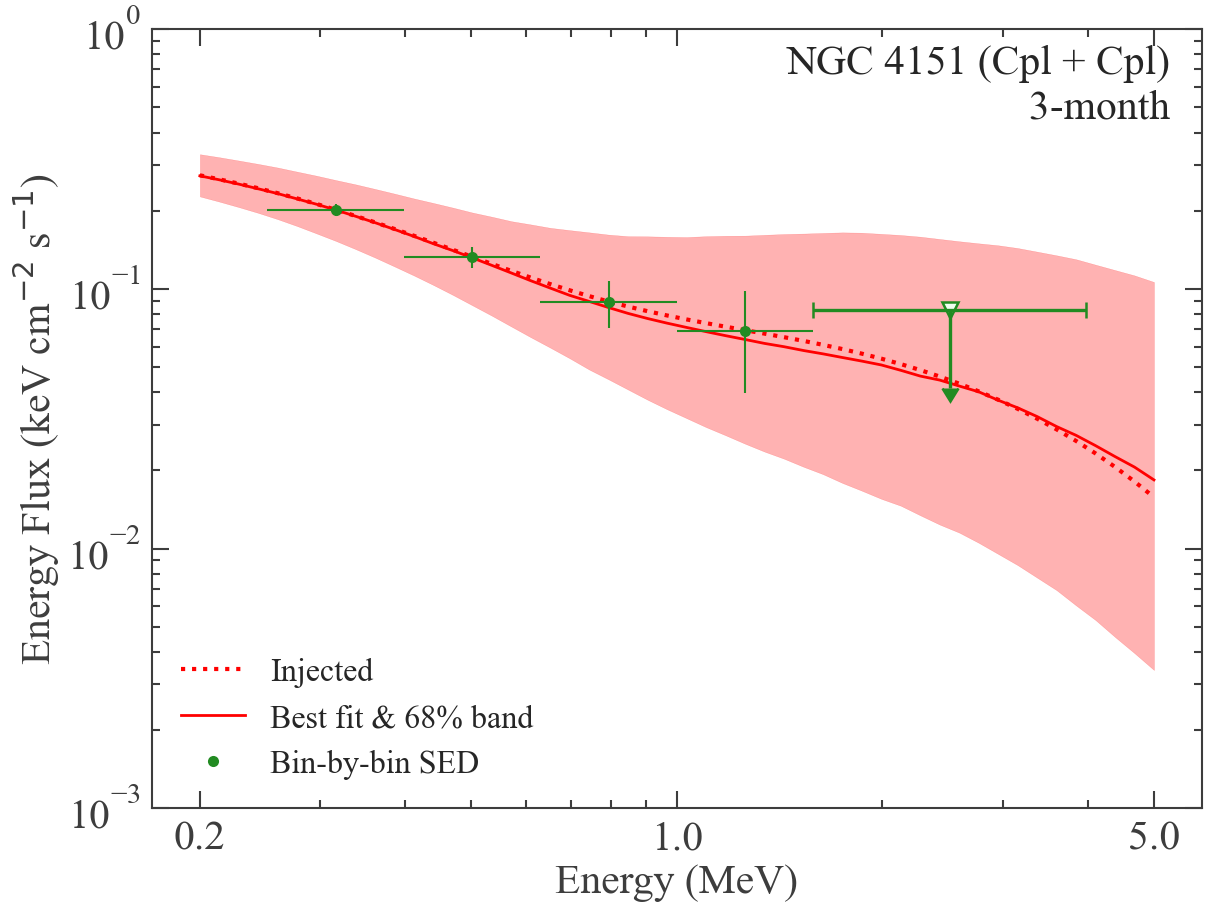

In [ ]:
FONT_SIZE = 30

plt.rcParams["agg.path.chunksize"] = 10000
plt.rcParams.update({"font.size": FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.linewidth"] = 1.5
plt.rcParams.update(
    {
        "font.weight": "550",
        "axes.titleweight": "550",
        "axes.labelweight": "550",
    }
)

def _make_xerr(df):
    return np.vstack(
        [
            df["e_ref_keV"] - df["e_min_keV"],
            df["e_max_keV"] - df["e_ref_keV"],
        ]
    )

def _split_sed_detections(df, ts_threshold=4.0):
    upper_limit_mask = df['is_upper_limit'].copy()

    if 'ts_value' in df.columns:
        upper_limit_mask = upper_limit_mask | (df['ts_value'] < ts_threshold)

    return (
        df.loc[~upper_limit_mask].copy(),
        df.loc[upper_limit_mask].copy(),
    )

n_sed_bins_200 = len(thermal_cosi_sed_df)

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)

ax.xaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', top='on', pad=8, labelsize=FONT_SIZE)
ax.xaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', top='on', pad=8)
ax.yaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', right='on', pad=8, labelsize=FONT_SIZE)
ax.yaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', right='on', pad=8)

ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)

det_200, ul_200 = _split_sed_detections(thermal_cosi_sed_df)

ax.plot(
    energy,
    energy * energy * flux_inj,
    color='red',
    ls=':',
    lw=3,
    label='Injected thermal model ($E_{c}$ = 200 keV)',
)
ax.plot(
    energy,
    energy * energy * flux_median,
    color='red',
    lw=2,
    label='Global COSI-only fit ($E_{c}$ = 200 keV)',
)
ax.fill_between(
    energy,
    energy * energy * flux_lo,
    energy * energy * flux_hi,
    alpha=0.3,
    color='red',
)

if not det_200.empty:
    detection_xerr_200 = _make_xerr(det_200)
    detection_yerr_200 = np.vstack(
        [
            np.maximum(det_200['sed_keV_cm2_s'] - det_200['sed_lo_keV_cm2_s'], 0),
            np.maximum(det_200['sed_hi_keV_cm2_s'] - det_200['sed_keV_cm2_s'], 0),
        ]
    )

    ax.errorbar(
        det_200['e_ref_keV'],
        det_200['sed_keV_cm2_s'],
        xerr=detection_xerr_200,
        yerr=detection_yerr_200,
        fmt='o',
        color='forestgreen',
        ecolor='forestgreen',
        elinewidth=1.5,
        capsize=4,
        markersize=8,
        label=f'Bin-by-bin SED ($E_{{c}}$ = 200 keV; {len(det_200)} detections out of {n_sed_bins_200} bins)',
    )

if not ul_200.empty:
    upper_xerr_200 = _make_xerr(ul_200)
    upper_y_200 = ul_200['sed_hi_keV_cm2_s'].to_numpy()
    upper_yerr_200 = np.maximum(0.5 * upper_y_200, np.finfo(float).tiny)

    ax.errorbar(
        ul_200['e_ref_keV'],
        upper_y_200,
        xerr=upper_xerr_200,
        yerr=upper_yerr_200,
        uplims=True,
        fmt='v',
        color='forestgreen',
        ecolor='forestgreen',
        markerfacecolor='honeydew',
        markeredgecolor='forestgreen',
        markeredgewidth=1.8,
        elinewidth=2.4,
        capsize=6,
        markersize=11,
        barsabove=True,
        zorder=6,
        label='_nolegend_',
    )

legend_handles = [
    plt.Line2D([], [], color='red', ls=':', lw=3, label='Injected'),
    plt.Line2D([], [], color='red', lw=2, label='Best fit & 68% band'),
]

if not det_200.empty:
    legend_handles.append(
        plt.Line2D([], [], color='forestgreen', marker='o', linestyle='None', markersize=8, label='Bin-by-bin SED')
    )
ax.text(
    0.98, 0.98,
    f'NGC 4151 (Cpl + Cpl) \n{exposure_4151}-month ',
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_ylim(1e-3, 1)

ax.xaxis.set_major_locator(mticker.FixedLocator([200, 1000, 5000]))
ax.xaxis.set_major_formatter(mticker.FixedFormatter(['0.2', '1.0', '5.0']))

ax.set_xlabel('Energy (MeV)', fontsize=FONT_SIZE)
ax.set_ylabel(r'Energy Flux (keV cm$^{-2}$ s$^{-1}$)', fontsize=FONT_SIZE)
ax.legend(handles=legend_handles, fontsize=23, loc='lower left', frameon=False)

save_path = f'/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/Papers/AGN_Corona_EC/Plots/NGC4151_Cpl_Cpl_Fit_200_{exposure_4151}Months_SED.pdf'
# plt.savefig(save_path)